# 소주제 A. 주조 제품 불량/정상 자동 분류

> **AI 기반 스마트 팩토리 품질관리 시스템 — CNN 전이학습 + Grad-CAM**
>
> K-Digital Training 딥러닝 12기 미니프로젝트

---

## 파이프라인 요약

| 단계 | 내용 |
|------|------|
| 1 | 환경 설정 및 패키지 임포트 |
| 2 | 데이터 탐색 (EDA) |
| 3 | 데이터 전처리 및 DataLoader |
| 4 | 모델 정의 (ResNet50 / VGG16 / EfficientNet-B0) |
| 5 | 학습 루프 구현 및 3개 모델 학습 |
| 6 | Training Curves 시각화 |
| 7 | Test Set 평가 및 혼동행렬 |
| 8 | Grad-CAM 시각화 |
| 9 | 최종 결과 저장 및 요약 |

## 1. 환경 설정 및 패키지 임포트

In [1]:
# --- 패키지 설치 (Colab 환경) ---
# !pip install -q grad-cam opencv-python

import os
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

# --- 한글 폰트 설정 ---
# Colab: matplotlib.rc('font', family='NanumGothic')
# macOS:
matplotlib.rc('font', family='AppleGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

# --- 시드 고정 ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- 디바이스 설정 ---
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Apple Silicon MPS 사용')
else:
    device = torch.device('cpu')
    print('CPU 사용 (GPU 없음)')

print(f'PyTorch: {torch.__version__}')
print(f'Device: {device}')

Apple Silicon MPS 사용
PyTorch: 2.10.0
Device: mps


## 2. 데이터 경로 설정 및 탐색적 데이터 분석 (EDA)

In [2]:
# --- 경로 설정 ---
# 로컬 실행 시 경로 (Colab은 Google Drive 마운트 후 수정)
BASE_DIR = Path('../')  # SubTopic_A_Casting_Classification/
DATA_DIR = Path('../../data/casting product image data for quality inspection/casting_data/casting_data')

TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR  = DATA_DIR / 'test'
MODEL_DIR = BASE_DIR / 'models'
RESULT_DIR = BASE_DIR / 'results'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# 경로 확인
assert TRAIN_DIR.exists(), f'Train 경로가 존재하지 않습니다: {TRAIN_DIR}'
assert TEST_DIR.exists(), f'Test 경로가 존재하지 않습니다: {TEST_DIR}'
print(f'Train: {TRAIN_DIR}')
print(f'Test:  {TEST_DIR}')

# --- 클래스별 이미지 수 ---
class_names = ['def_front', 'ok_front']
class_labels = ['Defective (불량)', 'OK (정상)']

train_counts = {}
test_counts = {}
for cls in class_names:
    train_counts[cls] = len(list((TRAIN_DIR / cls).glob('*.jpeg')))
    test_counts[cls] = len(list((TEST_DIR / cls).glob('*.jpeg')))

print('\n=== 데이터셋 분포 ===')
print(f'{"클래스":>15} | {"Train":>7} | {"Test":>6} | {"합계":>6}')
print('-' * 45)
for cls, label in zip(class_names, class_labels):
    total = train_counts[cls] + test_counts[cls]
    print(f'{label:>15} | {train_counts[cls]:>7,} | {test_counts[cls]:>6,} | {total:>6,}')
print('-' * 45)
print(f'{"합계":>15} | {sum(train_counts.values()):>7,} | {sum(test_counts.values()):>6,} | {sum(train_counts.values())+sum(test_counts.values()):>6,}')

Train: ../../data/casting product image data for quality inspection/casting_data/casting_data/train
Test:  ../../data/casting product image data for quality inspection/casting_data/casting_data/test

=== 데이터셋 분포 ===
            클래스 |   Train |   Test |     합계
---------------------------------------------
 Defective (불량) |   3,758 |    453 |  4,211
        OK (정상) |   2,875 |    262 |  3,137
---------------------------------------------
             합계 |   6,633 |    715 |  7,348


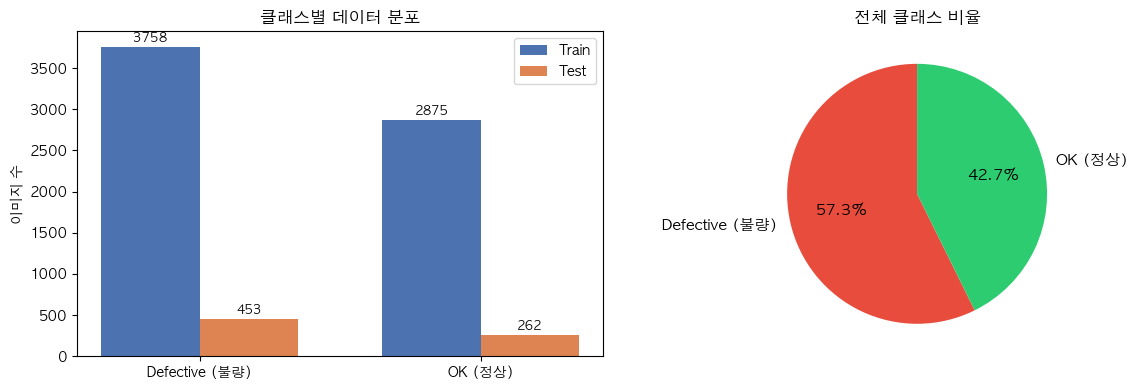

저장: ../results/02_class_distribution.png


In [3]:
# --- 클래스 분포 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 막대 그래프
x = np.arange(len(class_labels))
width = 0.35
bars1 = axes[0].bar(x - width/2, [train_counts[c] for c in class_names], width, label='Train', color='#4C72B0')
bars2 = axes[0].bar(x + width/2, [test_counts[c] for c in class_names], width, label='Test', color='#DD8452')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_labels)
axes[0].set_ylabel('이미지 수')
axes[0].set_title('클래스별 데이터 분포')
axes[0].legend()
axes[0].bar_label(bars1, padding=2, fontsize=9)
axes[0].bar_label(bars2, padding=2, fontsize=9)

# 파이 차트 (전체)
total_counts = [train_counts[c] + test_counts[c] for c in class_names]
colors = ['#E74C3C', '#2ECC71']
axes[1].pie(total_counts, labels=class_labels, autopct='%1.1f%%', colors=colors,
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('전체 클래스 비율')

plt.tight_layout()
plt.savefig(RESULT_DIR / '02_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {RESULT_DIR / "02_class_distribution.png"}')

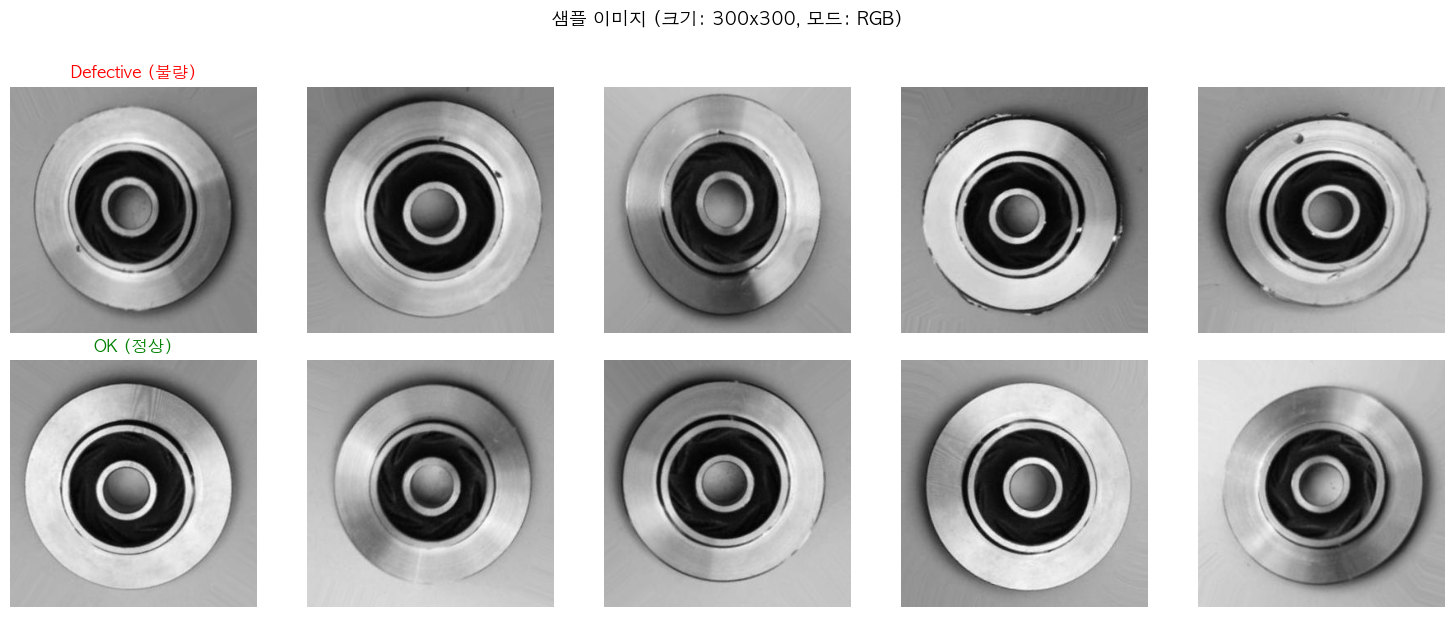

저장: ../results/01_sample_images.png


In [4]:
# --- 샘플 이미지 시각화 ---
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row, (cls, label) in enumerate(zip(class_names, class_labels)):
    img_dir = TRAIN_DIR / cls
    img_files = sorted(img_dir.glob('*.jpeg'))[:5]
    for col, img_path in enumerate(img_files):
        img = Image.open(img_path)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f'{label}', fontsize=12, fontweight='bold',
                                     color='red' if 'def' in cls else 'green')

# 첫 번째 이미지 크기 확인
sample_img = Image.open(list((TRAIN_DIR / 'def_front').glob('*.jpeg'))[0])
fig.suptitle(f'샘플 이미지 (크기: {sample_img.size[0]}x{sample_img.size[1]}, 모드: {sample_img.mode})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULT_DIR / '01_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {RESULT_DIR / "01_sample_images.png"}')

## 3. 데이터 전처리 및 DataLoader 구성

In [5]:
# --- 하이퍼파라미터 ---
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0  # 노트북에서는 0 (멀티프로세싱 pickle 오류 방지)
NUM_CLASSES = 2

# ImageNet 정규화 값
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# --- Transform 정의 ---
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


# --- Train/Val 분리 시 다른 Transform 적용을 위한 Wrapper ---
class TransformedSubset(Dataset):
    """Subset에 별도 transform을 적용하는 래퍼 클래스"""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        # ImageFolder가 이미 PIL Image를 반환하므로,
        # 원본 dataset의 transform을 None으로 설정해야 함
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)


# --- 데이터 로드 (transform=None으로 PIL Image 유지) ---
train_full_raw = datasets.ImageFolder(str(TRAIN_DIR), transform=None)
test_dataset   = datasets.ImageFolder(str(TEST_DIR), transform=test_transform)

print(f'클래스 매핑: {train_full_raw.class_to_idx}')
# def_front=0 (불량), ok_front=1 (정상)

# --- Train/Val 분리 (80:20) ---
total_size = len(train_full_raw)
train_size = int(0.8 * total_size)
val_size   = total_size - train_size

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(train_full_raw, [train_size, val_size], generator=generator)

# Subset에 각각 다른 transform 적용
train_dataset = TransformedSubset(train_subset, transform=train_transform)
val_dataset   = TransformedSubset(val_subset, transform=test_transform)

# --- DataLoader ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'\n=== DataLoader 구성 ===')
print(f'Train: {len(train_dataset):,}장 ({len(train_loader)} batches)')
print(f'Val:   {len(val_dataset):,}장 ({len(val_loader)} batches)')
print(f'Test:  {len(test_dataset):,}장 ({len(test_loader)} batches)')

# 배치 확인
imgs, labels = next(iter(train_loader))
print(f'\n배치 shape: {imgs.shape}')  # [32, 3, 224, 224]
print(f'레이블 shape: {labels.shape}, 값: {labels[:8].tolist()}')

클래스 매핑: {'def_front': 0, 'ok_front': 1}

=== DataLoader 구성 ===
Train: 5,306장 (166 batches)
Val:   1,327장 (42 batches)
Test:  715장 (23 batches)


Traceback (most recent call last):
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=106, pipe_handle=120)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/ml/lib/python3.13/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/opt/anaconda3/envs/ml/lib/python3.13/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'TransformedSubset' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>


BrokenPipeError: [Errno 32] Broken pipe

## 4. 모델 정의 — 3종 비교 아키텍처

| 모델 | 백본 | 분류층 | 학습 파라미터 |
|------|------|--------|-------------|
| ResNet50 | ImageNet (Frozen) | 2048→256→2 | ~131K |
| VGG16 | ImageNet (Frozen) | 4096→2 | ~8K |
| EfficientNet-B0 | ImageNet (Frozen) | 1280→2 | ~2.5K |

In [ ]:
def build_model(model_name, num_classes=2, freeze_backbone=True):
    """
    사전학습 모델 로드 + 분류층 교체 + backbone freeze

    Args:
        model_name: 'resnet50', 'vgg16', 'efficientnet_b0'
        num_classes: 출력 클래스 수
        freeze_backbone: True면 feature extractor 동결
    """
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        # 분류층 교체: 2048 → 256 → ReLU → Dropout → 2
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    elif model_name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        # 분류층 마지막만 교체: 4096 → 2
        model.classifier[-1] = nn.Linear(4096, num_classes)

    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        # 분류층 교체: Dropout → 1280 → 2
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    else:
        raise ValueError(f'지원하지 않는 모델: {model_name}')

    return model.to(device)


def count_parameters(model):
    """전체/학습 가능 파라미터 수 반환"""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# --- 모델 확인 ---
print(f'{"모델":>18} | {"전체 파라미터":>15} | {"학습 파라미터":>15}')
print('-' * 55)
for name in ['resnet50', 'vgg16', 'efficientnet_b0']:
    m = build_model(name)
    total, trainable = count_parameters(m)
    print(f'{name:>18} | {total:>15,} | {trainable:>15,}')
    del m
torch.cuda.empty_cache() if torch.cuda.is_available() else None

## 5. 학습 루프 구현 및 3개 모델 학습

In [ ]:
# --- 학습 하이퍼파라미터 ---
EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5  # Early Stopping


def train_one_epoch(model, loader, criterion, optimizer):
    """1 에포크 학습"""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion):
    """검증/테스트 평가"""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def train_model(model, model_name, train_loader, val_loader, epochs=EPOCHS):
    """전체 학습 파이프라인"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    patience_counter = 0
    save_path = MODEL_DIR / f'best_{model_name}.pth'

    print(f'\n{"="*60}')
    print(f' 학습 시작: {model_name.upper()}')
    print(f'{"="*60}')

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step(val_acc)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Best model 저장
        improved = ''
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
            improved = ' ★ Best'
        else:
            patience_counter += 1

        lr = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch:2d}/{epochs} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
              f'LR: {lr:.1e}{improved}')

        # Early Stopping
        if patience_counter >= PATIENCE:
            print(f'  → Early Stopping (patience={PATIENCE})')
            break

    # Best model 로드
    model.load_state_dict(torch.load(save_path, weights_only=True))
    print(f'  → Best Val Acc: {best_val_acc:.4f} (저장: {save_path.name})')

    return model, history

In [ ]:
# --- 3개 모델 순차 학습 ---
model_names = ['resnet50', 'vgg16', 'efficientnet_b0']
all_results = {}

for name in model_names:
    model = build_model(name, num_classes=NUM_CLASSES, freeze_backbone=True)
    model, history = train_model(model, name, train_loader, val_loader)
    all_results[name] = {'model': model, 'history': history}

print(f'\n{"="*60}')
print(' 전체 학습 완료!')
print(f'{"="*60}')

## 6. Training Curves 시각화

In [ ]:
# --- 학습 곡선 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {'resnet50': '#E74C3C', 'vgg16': '#3498DB', 'efficientnet_b0': '#2ECC71'}
display_names = {'resnet50': 'ResNet50', 'vgg16': 'VGG16', 'efficientnet_b0': 'EfficientNet-B0'}

for name in model_names:
    h = all_results[name]['history']
    epochs_range = range(1, len(h['train_loss']) + 1)
    c = colors[name]
    dn = display_names[name]

    # Loss
    axes[0].plot(epochs_range, h['train_loss'], '-', color=c, alpha=0.7, label=f'{dn} Train')
    axes[0].plot(epochs_range, h['val_loss'], '--', color=c, label=f'{dn} Val')

    # Accuracy
    axes[1].plot(epochs_range, h['train_acc'], '-', color=c, alpha=0.7, label=f'{dn} Train')
    axes[1].plot(epochs_range, h['val_acc'], '--', color=c, label=f'{dn} Val')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('학습/검증 Loss 비교')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('학습/검증 Accuracy 비교')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / '03_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {RESULT_DIR / "03_training_curves.png"}')

## 7. Test Set 평가 및 혼동행렬

In [ ]:
@torch.no_grad()
def evaluate_on_test(model, loader):
    """테스트셋 전체 예측 + 지표 산출"""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='binary', pos_label=0),
        'recall': recall_score(all_labels, all_preds, average='binary', pos_label=0),
        'f1': f1_score(all_labels, all_preds, average='binary', pos_label=0),
    }

    return metrics, all_preds, all_labels, all_probs


# --- 3개 모델 테스트 평가 ---
test_results = {}
print(f'{"모델":>18} | {"Accuracy":>9} | {"Precision":>10} | {"Recall":>8} | {"F1-Score":>9}')
print('-' * 65)

for name in model_names:
    model = all_results[name]['model']
    metrics, preds, labels, probs = evaluate_on_test(model, test_loader)
    test_results[name] = {'metrics': metrics, 'preds': preds, 'labels': labels, 'probs': probs}

    dn = display_names[name]
    print(f'{dn:>18} | {metrics["accuracy"]:>8.4f} | {metrics["precision"]:>9.4f} | '
          f'{metrics["recall"]:>7.4f} | {metrics["f1"]:>8.4f}')

# 최고 모델
best_name = max(test_results, key=lambda n: test_results[n]['metrics']['f1'])
print(f'\n★ 최고 모델 (F1 기준): {display_names[best_name]}')

In [ ]:
# --- 혼동행렬 시각화 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm_labels = ['Defective', 'OK']

for idx, name in enumerate(model_names):
    preds = test_results[name]['preds']
    labels = test_results[name]['labels']
    cm = confusion_matrix(labels, preds)
    acc = test_results[name]['metrics']['accuracy']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=cm_labels, yticklabels=cm_labels, cbar=False,
                annot_kws={'size': 14})
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)
    axes[idx].set_title(f'{display_names[name]}\nAccuracy: {acc:.4f}', fontsize=12, fontweight='bold')

plt.suptitle('모델별 혼동행렬 (Test Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULT_DIR / '04_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {RESULT_DIR / "04_confusion_matrices.png"}')

# 상세 Classification Report (최고 모델)
print(f'\n=== {display_names[best_name]} Classification Report ===')
print(classification_report(
    test_results[best_name]['labels'],
    test_results[best_name]['preds'],
    target_names=cm_labels
))

## 8. Grad-CAM 시각화

> 모델이 **어디를 보고** 불량/정상을 판단했는지 시각적으로 확인합니다.

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def get_target_layer(model, model_name):
    """모델별 Grad-CAM 타겟 레이어 반환"""
    if model_name == 'resnet50':
        return [model.layer4[-1]]
    elif model_name == 'vgg16':
        return [model.features[-1]]
    elif model_name == 'efficientnet_b0':
        return [model.features[-1]]


def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """정규화 역변환 (시각화용)"""
    t = tensor.clone()
    for ch, m, s in zip(t, mean, std):
        ch.mul_(s).add_(m)
    return t.clamp(0, 1)


# --- 최고 모델로 Grad-CAM 수행 (CPU에서 실행 — MPS gradient 이슈 방지) ---
best_model_cpu = all_results[best_name]['model'].cpu().eval()
# backbone unfreeze (frozen이면 gradient가 없어 Grad-CAM 실패)
for param in best_model_cpu.parameters():
    param.requires_grad = True
target_layers = get_target_layer(best_model_cpu, best_name)

# 테스트셋에서 샘플 선택: defective 4장 + ok 4장
indices = {0: [], 1: []}
for idx in range(len(test_dataset)):
    _, label = test_dataset[idx]
    if len(indices[label]) < 4:
        indices[label].append(idx)
    if all(len(v) >= 4 for v in indices.values()):
        break
sample_indices = indices[0] + indices[1]

# Grad-CAM 시각화
fig, axes = plt.subplots(8, 3, figsize=(12, 28))
column_titles = ['원본 이미지', 'Grad-CAM 히트맵', '오버레이']
cm_labels = ['Defective', 'OK']

cam = GradCAM(model=best_model_cpu, target_layers=target_layers)

for row, idx in enumerate(sample_indices):
    img_tensor, true_label = test_dataset[idx]
    input_tensor = img_tensor.unsqueeze(0)  # CPU 텐서 유지

    # 예측 (CPU)
    with torch.no_grad():
        output = best_model_cpu(input_tensor)
        prob = torch.softmax(output, dim=1)
        pred_label = output.argmax(1).item()
        confidence = prob[0, pred_label].item()

    # Grad-CAM (CPU)
    targets = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # 역정규화
    rgb_img = denormalize(img_tensor).permute(1, 2, 0).numpy()
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # 정답/오답 표시
    is_correct = pred_label == true_label
    true_str = cm_labels[true_label]
    pred_str = cm_labels[pred_label]
    color = 'green' if is_correct else 'red'
    title = f'정답: {true_str} | 예측: {pred_str} ({confidence:.1%})'

    # 원본
    axes[row, 0].imshow(rgb_img)
    axes[row, 0].set_title(title, fontsize=9, color=color, fontweight='bold')
    axes[row, 0].axis('off')

    # 히트맵
    axes[row, 1].imshow(grayscale_cam, cmap='jet')
    axes[row, 1].axis('off')

    # 오버레이
    axes[row, 2].imshow(cam_image)
    axes[row, 2].axis('off')

# 열 제목
for col, title in enumerate(column_titles):
    axes[0, col].set_title(f'{title}\n{axes[0, col].get_title()}', fontsize=10)

fig.suptitle(f'Grad-CAM 시각화 ({display_names[best_name]})', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(RESULT_DIR / '05_gradcam_best_model.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {RESULT_DIR / "05_gradcam_best_model.png"}')


## 9. 최종 결과 저장 및 요약

In [ ]:
# --- 최종 결과 JSON 저장 ---
summary = {
    'project': '소주제 A — 주조 제품 불량/정상 자동 분류',
    'dataset': 'Casting Product Image Data for Quality Inspection',
    'image_size': '300x300 → 224x224',
    'classes': {'0': 'Defective (불량)', '1': 'OK (정상)'},
    'data_split': {
        'train': len(train_dataset),
        'val': len(val_dataset),
        'test': len(test_dataset),
    },
    'training_config': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'optimizer': 'Adam',
        'scheduler': 'ReduceLROnPlateau (factor=0.5, patience=3)',
        'early_stopping_patience': PATIENCE,
        'seed': SEED,
    },
    'models': {},
    'best_model': display_names[best_name],
}

for name in model_names:
    m = test_results[name]['metrics']
    summary['models'][display_names[name]] = {
        'accuracy': round(m['accuracy'], 4),
        'precision': round(m['precision'], 4),
        'recall': round(m['recall'], 4),
        'f1_score': round(m['f1'], 4),
    }

json_path = RESULT_DIR / '06_final_summary.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f'결과 JSON 저장: {json_path}\n')

# --- 최종 요약 출력 ---
print('=' * 65)
print(' 소주제 A — 주조 제품 불량/정상 자동 분류 | 최종 결과')
print('=' * 65)
print(f'\n{"모델":>18} | {"Accuracy":>9} | {"Precision":>10} | {"Recall":>8} | {"F1-Score":>9}')
print('-' * 65)
for name in model_names:
    m = test_results[name]['metrics']
    dn = display_names[name]
    marker = ' ★' if name == best_name else ''
    print(f'{dn:>18} | {m["accuracy"]:>8.2%} | {m["precision"]:>9.2%} | '
          f'{m["recall"]:>7.2%} | {m["f1"]:>8.2%}{marker}')

print(f'\n★ 최고 모델: {display_names[best_name]}')
print(f'\n저장된 파일:')
for f in sorted(RESULT_DIR.glob('*')):
    print(f'  → results/{f.name}')
for f in sorted(MODEL_DIR.glob('*.pth')):
    print(f'  → models/{f.name}')